State to teleport: Statevector([0.70710678+0.j        , 0.67552491+0.20896434j,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ],
            dims=(2, 2, 2))
     ┌───┐┌────────┐     ┌───┐┌─┐           
q_0: ┤ H ├┤ P(0.3) ├──■──┤ H ├┤M├──────■────
     ├───┤└────────┘┌─┴─┐└┬─┬┘└╥┘      │    
q_1: ┤ H ├────■─────┤ X ├─┤M├──╫───■───┼────
     └───┘  ┌─┴─┐   └───┘ └╥┘  ║ ┌─┴─┐ │ ┌─┐
q_2: ───────┤ X ├──────────╫───╫─┤ X ├─■─┤M├
            └───┘          ║   ║ └───┘   └╥┘
c: 3/══════════════════════╩═══╩══════════╩═
                           1   0          2 
Measurement results: {'011': 123, '000': 140, '101': 149, '001': 123, '100': 130, '111': 137, '110': 115, '010': 107}


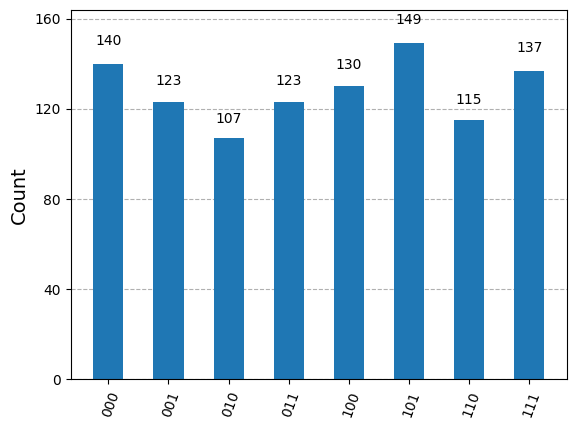

In [1]:
#Based on the theory which we have learned for quantum teleportation, qiskit code is written.
#Quantum Teleportation Protocol 
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# Step 1: Create a 3-qubit circuit
qc = QuantumCircuit(3, 3)

# Step 2: Prepare an arbitrary state to teleport (example: |ψ⟩ = α|0⟩ + β|1⟩)
qc.h(0)          # put qubit0 in |+>
qc.p(0.3, 0)     # add a phase

# Visualize initial state
initial_state = Statevector.from_instruction(qc)
print("State to teleport:", initial_state)

# Step 3: Create entanglement between qubit1 and qubit2
qc.h(1)
qc.cx(1, 2)

# Step 4: Bell measurement on qubit0 & qubit1
qc.cx(0, 1)
qc.h(0)
qc.measure([0, 1], [0, 1])

# Step 5: Conditional corrections for Bob (qubit2)
qc.cx(1, 2)
qc.cz(0, 2)

# Step 6: Measure Bob's qubit
qc.measure(2, 2)

print(qc.draw())

# Simulator backend
sim = Aer.get_backend("aer_simulator")

# Run the circuit
qc_compiled = qc.copy()
qc_compiled = sim.run(qc_compiled, shots=1024).result()

# Get counts
counts = qc_compiled.get_counts()
print("Measurement results:", counts)
plt.show()
# Plot results
plot_histogram(counts)
#plt.show()


# Task to be submitted on two classical bit transmittion using a single qubit (superdense coding)
# Algorithm to build superdense coding

# Take the reference of following diagram
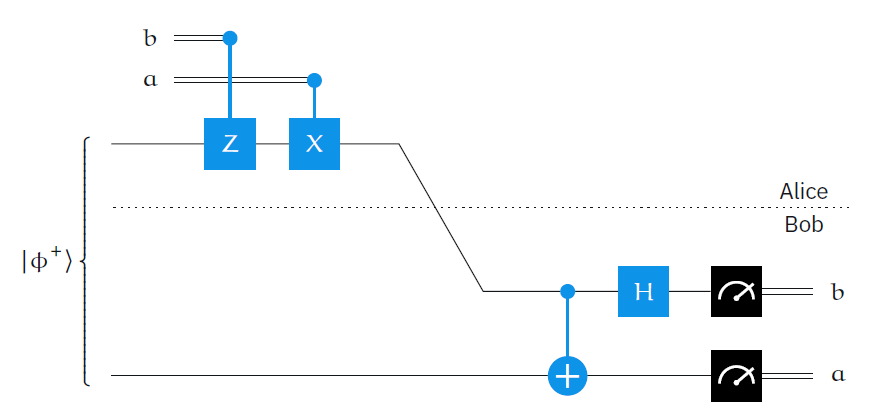


Encoding message 00
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├──■────■──┤ H ├┤M├
     └───┘┌─┴─┐┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├┤ X ├─┤M├──╫─
          └───┘└───┘ └╥┘  ║ 
c: 2/═════════════════╩═══╩═
                      1   0 
Decoded bits: {'00': 1024}

Encoding message 01
     ┌───┐     ┌───┐     ┌───┐┌─┐
q_0: ┤ H ├──■──┤ X ├──■──┤ H ├┤M├
     └───┘┌─┴─┐└───┘┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├─────┤ X ├─┤M├──╫─
          └───┘     └───┘ └╥┘  ║ 
c: 2/══════════════════════╩═══╩═
                           1   0 
Decoded bits: {'10': 1024}

Encoding message 10
     ┌───┐     ┌───┐     ┌───┐┌─┐
q_0: ┤ H ├──■──┤ Z ├──■──┤ H ├┤M├
     └───┘┌─┴─┐└───┘┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├─────┤ X ├─┤M├──╫─
          └───┘     └───┘ └╥┘  ║ 
c: 2/══════════════════════╩═══╩═
                           1   0 
Decoded bits: {'01': 1024}

Encoding message 11
     ┌───┐     ┌───┐┌───┐     ┌───┐┌─┐
q_0: ┤ H ├──■──┤ Z ├┤ X ├──■──┤ H ├┤M├
     └───┘┌─┴─┐└───┘└───┘┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├──────────┤ X ├─┤M├──╫─


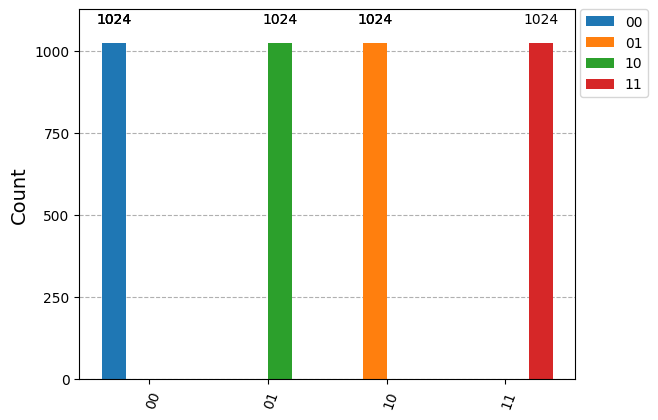

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Simulator
sim = Aer.get_backend('aer_simulator')

messages = {
    '00': (0, 0),
    '01': (1, 0),
    '10': (0, 1),
    '11': (1, 1)
}

results = {}

for msg, (a, b) in messages.items():
    print(f"\nEncoding message {msg}")
    
    # Step 1: Create circuit with 2 qubits and 2 classical bits
    qc = QuantumCircuit(2, 2)
    
    # Step 2: Create entangled pair |Φ+>
    qc.h(0)
    qc.cx(0, 1)
    
    # Step 3: Alice encodes her 2 classical bits    
    if b == 1:
        qc.z(0)   # Apply Z if bit b = 1
    if a == 1:
        qc.x(0)   # Apply X if bit a = 1
    
    # Step 4: Alice sends her qubit to Bob
    # (No code step needed — just a conceptual transfer)
    
    # Step 5: Bob decodes
    qc.cx(0, 1)
    qc.h(0)
    
    # Step 6: Bob measures both qubits
    qc.measure([0, 1], [0, 1])
    
    # Draw the circuit
    print(qc.draw())
    
    # Step 7: Run on simulator
    compiled = transpile(qc, sim)
    result = sim.run(compiled, shots=1024).result()
    
    # Get results
    counts = result.get_counts()
    print("Decoded bits:", counts)
    results[msg] = counts

plt.show()
plot_histogram(list(results.values()), legend=list(results.keys()))